In [7]:
import numpy as np
import pandas as pd

np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_samples = np.random.multivariate_normal(mu_vec1, cov_mat1, 2)

df  = pd.DataFrame(class1_samples,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_samples = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_samples,columns=['feature1','feature2','feature3'])
df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)
df = df.sample(frac=1) # Corrected to shuffle all available data

In [8]:
df.head()

,feature1,feature2,feature3,target
11,2.968435,0.452212,0.320582,0
4,1.322272,1.060343,-0.043450,0
9,2.267248,1.173634,-0.223255,0
3,2.772258,0.652541,1.670140,0
21,0.731858,0.517441,2.244610,0


In [10]:
import plotly.express as px

fig = px.scatter_3d(df, x='feature1', y='feature2', z='feature3',
              color=df['target'].astype(str))
fig.update_traces(marker=dict(size=5, line=dict(width=2, color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()

In [12]:
#Step1-> Applying standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [13]:
#Step 2-> Find cavariance matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print(covariance_matrix)

[[ 1.04761905  0.16743474 -0.13244158]
 [ 0.16743474  1.04761905  0.22932793]
 [-0.13244158  0.22932793  1.04761905]]


In [14]:
#Step3-> Find Eigen values and Eigen vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
print(eigen_values)
print(eigen_vectors)

[0.69161874 1.16981329 1.28142511]
[[-0.51272402  0.84000519  0.17749752]
 [ 0.6222218   0.22110981  0.75096637]
 [-0.5915692  -0.49548132  0.63603785]]


In [15]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


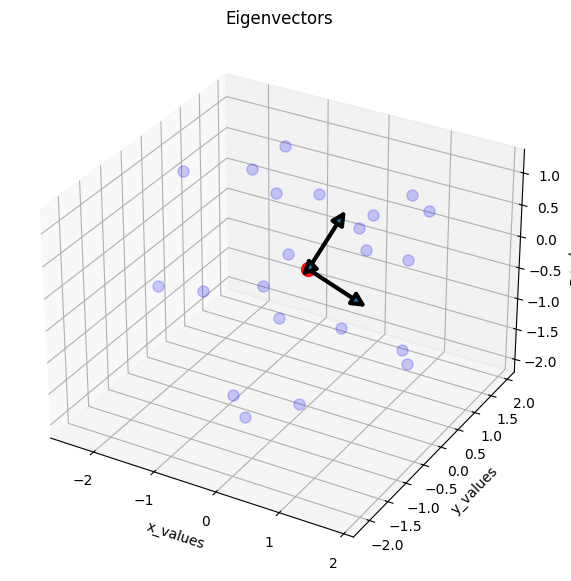

In [21]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, ax, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs
        self.ax = ax

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.ax.get_proj())
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)

    def do_3d_projection(self, renderer=None):
        # Return the average z-coordinate for depth sorting
        return (self._verts3d[2][0] + self._verts3d[2][1]) / 2.0

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
# The second ax.plot call plots a single point at the mean of the features.
# It seems intended to mark the origin of the eigenvectors, but it's incorrectly structured.
# For now, I'll comment it out or you can adjust it to plot a single point if needed.
# ax.plot([df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()],0, markersize=10, color='red', alpha=0.9)
ax.plot(df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean(), 'o', markersize=10, color='red', alpha=0.9)

x_mean = df['feature1'].mean()
y_mean = df['feature2'].mean()
z_mean = df['feature3'].mean()

for v in eigen_vectors.T:
    a = Arrow3D([x_mean, x_mean + v[0]], [y_mean, y_mean + v[1]], [z_mean, z_mean + v[2]], ax=ax, mutation_scale=20, lw=3, arrowstyle="-|>")
    ax.add_artist(a)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [23]:
pc = eigen_vectors[0:2]
pc

array([[-0.51272402,  0.84000519,  0.17749752],
       [ 0.6222218 ,  0.22110981,  0.75096637]])

In [25]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)

new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-1.475035,0.503539,0
1,0.034671,-0.549500,0
2,-0.314061,-0.093890,0
3,-0.874478,1.510651,0
4,0.052635,0.709354,0


In [26]:
new_df['target'] = new_df['target'].astype(str)
fig = px.scatter(new_df, x='PC1', y='PC2',
              color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=5, line=dict(width=2, color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()